In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 

from scipy.special import lambertw
from scipy.stats import poisson 

import scipy.sparse
from matplotlib.lines import Line2D 


# Plot

In [2]:
# ! cp -r ~/adipose_ln/atac/res/VIB_10xmultiome_2_OG/cluster_barcodes/ ~/adipose_ln/atac/res/VIB_10xmultiome_2_WS3000/.

In [3]:
precision=1e-10

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_RES'

In [4]:
# ws = 2000000
# ws = 1000000
# ws = 100000
# ws = 50000  # Might be too big
# ws = 30000  # might be too big
# ws = 10000
# ws=5000
ws = 3000
# ws=500
# ws=300

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS{ws}'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [5]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [6]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [7]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [8]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [9]:
def calculate_moment(tn5_inser_array:np.ndarray, return_freq:bool=False, print_debug:bool=False):
    cur, freq = np.unique(tn5_inser_array, return_counts=True)
    if print_debug:
        print(cur, freq)
    if cur[0] < precision:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)
    
    P0 = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if return_freq:
        return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0, cur_none, freq_none
    
    return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0


def calculate_moment_fix(tn5_inser_array:np.ndarray, return_freq:bool=False, print_debug:bool=False):
    cur, freq = np.unique(tn5_inser_array, return_counts=True)
    if print_debug:
        print(cur, freq)
    if cur[0] < precision:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    cur_none = (cur_none + 1) // 2 # adjust for paired-end sequencing
    
    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)
    
    P0 = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if return_freq:
        return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0, cur_none, freq_none

    return Mtotal, M1, non0_mean, non0_2ndorder_moment, P0


def mle_estimate(tn5_insert_array:scipy.sparse, print_debug:bool=False, return_freq:bool=False):
    
    flag = None
    Mtotal = tn5_insert_array.shape[1] # total number of windows
    
    row_indices, col_indices =tn5_insert_array.nonzero()
    non0_insert = tn5_insert_array[row_indices, col_indices].toarray().flatten()
    Mp = non0_insert.shape[0]
    
    cur, freq = np.unique(non0_insert, return_counts=True)
    
    non0_insert_adjusted = (non0_insert + 1) // 2 # adjust for paired-end sequencing
    cur_adjusted, freq_adjusted = np.unique(non0_insert_adjusted, return_counts=True)
    
    p_non0 = freq_adjusted / Mp
    mean_adjusted = np.sum( cur_adjusted * p_non0 )

    # Lambert W function requires (-M1 * exp(-M1)) >= -1/e
    if mean_adjusted <= 1:
        mle_lambda = None
        P0 = None
        if return_freq:
            return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag
        return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag

    mle_lambda = lambertw( -mean_adjusted * np.exp(-mean_adjusted) , k=0).real + mean_adjusted
    P0 = np.exp(-mle_lambda)
    
    if mle_lambda <= 0:
        P0 = None
    
    if return_freq:
        return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag
    return Mtotal, Mp, mean_adjusted, mle_lambda, P0, cur_adjusted, freq_adjusted, cur, freq, flag


def kl_divergence(mle_lambda, cur, freq):
    """ Compute KL divergence D_KL(P||Q) for discrete distributions
        p and q are arrays of the same length representing probability distributions
    """
    # q is from Poisson distribution with parameter mle_lambda
    
    p = freq / np.sum(freq)
    log_q = np.array([poisson.logpmf(k, mle_lambda) for k in cur]) 
    
    divergence = np.sum( p * (np.log(p) - log_q) )
    
    return divergence

In [10]:
# calcualte entropy without 0-insertion windows 
def calculate_entropy(tn5_insertion_array:np.ndarray):
    # tn5_insert_freq[bc].toarray()
    Mtotal, M1, non0_mean, non0_2ndorder_moment, p0_open_region, cur_none, freq_none = calculate_moment(tn5_insertion_array, return_freq=True)

    if p0_open_region < 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
    else:
        Nwindows_0inser_open_region = np.floor(p0_open_region / (1 - p0_open_region) * M1)

        Nwindows_0inser_open_region = np.max((Nwindows_0inser_open_region, Mtotal - M1))

    if Nwindows_0inser_open_region is None:
        Entropy_final = None
    else:
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)
        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))

        # calculate entropy
        posi_freq = total_freq[total_freq > 0]
        p_final = posi_freq / posi_freq.sum()
        Entropy_final = -np.sum(p_final * np.log2(p_final))
    return Entropy_final


## Calcualte multiple entropies: entropy of mixture distribution, entropy of open region, entropy of final distribution
def calcualte_multiple_entropies(tn5_insert_array:np.ndarray, return_all_paras:bool=False):
    Mtotal, M1, non0_mean, non0_2ndorder_moment, p0_open_region, cur_none, freq_none = calculate_moment_fix(tn5_insert_array, return_freq=True)

    if p0_open_region <= 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
        Entropy_mixturedist = None
        Entropy_open_region = None
        Entropy_final = None
    else:
        Nwindows_0inser_open_region = np.floor(M1 / ( 1- p0_open_region) * p0_open_region )
        Nwindows_0inser_open_region = np.min((Nwindows_0inser_open_region, Mtotal - M1))
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)

        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))

        # calculate entropy of mix states
        p_stats = np.array([Nwindows_closed_region, Mtotal - Nwindows_closed_region]) / Mtotal
        Entropy_state = -np.sum(p_stats * np.log2(p_stats))

        open_region_freq = total_freq[1:]
        open_region_freq_non0 = open_region_freq[open_region_freq > 0]
        open_region_p = open_region_freq_non0 / open_region_freq_non0.sum()

        # calculate entropy as a mixture distribution 
        Entropy_open_region = -np.sum(open_region_p * np.log2(open_region_p))
        Entropy_mixturedist = Entropy_state + (1 - Nwindows_closed_region / Mtotal) * Entropy_open_region

        # calculate entropy of final distribution -- Simply breaking down 0-freq to from open and closed regions
        posi_freq = total_freq[total_freq > 0]
        p_final = posi_freq / posi_freq.sum()
        Entropy_final = -np.sum(p_final * np.log2(p_final))

    if not return_all_paras:
        return Entropy_mixturedist, Entropy_open_region, Entropy_final
    
    other_paras = (non0_mean, non0_2ndorder_moment, p0_open_region)
    return Entropy_mixturedist, Entropy_open_region, Entropy_final, other_paras


def break_down_freq(tn5_insert_array:np.ndarray):
    cur, freq = np.unique(tn5_insert_array, return_counts=True)
    if cur[0] == 0:
        freq_none = freq[1:]
        cur_none = cur[1:]
    else:
        freq_none = freq
        cur_none = cur

    Mtotal = freq.sum() 
    M1 = freq_none.sum()
    
    non0_p = freq_none / np.sum(freq_none)
    non0_mean = np.sum(cur_none * non0_p)
    non0_2ndorder_moment = np.sum( cur_none**2 * non0_p)


    p0_open_region = 1 - (non0_2ndorder_moment - non0_mean) / non0_mean**2

    if p0_open_region < 0 or p0_open_region >= 1:
        Nwindows_0inser_open_region = None
    else:
        Nwindows_0inser_open_region = np.floor(p0_open_region / (1 - p0_open_region) * M1)
        Nwindows_0inser_open_region = np.max((Nwindows_0inser_open_region, Mtotal - M1))

    if Nwindows_0inser_open_region is None:
        total_freq = np.concatenate(([None, None], freq_none))
    else:
        Nwindows_closed_region = int(Mtotal - M1 - Nwindows_0inser_open_region)
        total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_none))
    
    total_cur = np.concatenate(([-1, 0], cur_none))

    return total_cur, total_freq

################

# Calculate Entropy using MLE estimate 
def mixdist_mle_entropy(tn5_insert_array:scipy.sparse):
    Mtotal, Mp, mean_non0, mle_lambda, p0, cur_adjusted, freq_adjusted,  cur, freq, flag = mle_estimate(tn5_insert_array, return_freq=True)

    if p0 is None:
        Entropy_mixturedist = None
        Entropy_open_region = None
        Entropy_open_region_noadj = None
        divergence = None
        p_closed_state = None
    else:
        Nwindows_0inser_open_region = np.floor(Mp / ( 1- p0) * p0 )
        Nwindows_0inser_open_region = np.min((Nwindows_0inser_open_region, Mtotal - Mp))
        Nwindows_closed_region = Mtotal - Mp - Nwindows_0inser_open_region

        #total_freq = np.concatenate(([Nwindows_closed_region, Nwindows_0inser_open_region], freq_adjusted))

        # calculate entropy of mix states
        p_closed_state = Nwindows_closed_region / Mtotal
        p_states = np.array([p_closed_state, 1 - p_closed_state])
        Entropy_state = -np.sum(p_states * np.log2(p_states))
        
        # calculate entropy as a mixture distribution 
        if Nwindows_0inser_open_region > 0:
            open_region_p = np.concatenate( ([Nwindows_0inser_open_region ], freq_adjusted) )
        else:
            open_region_p = freq_adjusted
        open_region_p = open_region_p / (Mp + Nwindows_0inser_open_region)
        Entropy_open_region = -np.sum(open_region_p * np.log2(open_region_p))

        # # Calculate the open region entropy using unadjusted freq (for comparison)
        p = freq/Mp
        Entropy_open_region_noadj = -np.sum(p * np.log2(p))
        
        Entropy_mixturedist = Entropy_state + (1 - p_closed_state) * Entropy_open_region
        # flag =  Entropy_state + (1 - p_closed_state) * Entropy_open_region_noadj # to test the difference
        #Entropy_mixturedist = Entropy_state + (1 - p_closed_state) * entropy_non0_part # without adjusted
        divergence = kl_divergence(mle_lambda, cur_adjusted, freq_adjusted)
    return Entropy_mixturedist, Entropy_open_region, Entropy_open_region_noadj, mle_lambda, p0, p_closed_state, divergence
    

In [11]:
# calcualte entropy without 0-insertion windows 
for bc in tn5_insert_freq.keys():
    if bc not in entropy_df.index:
        continue
    else:
        Entropy_mixturedist, Entropy_open_region, Entropy_open_region_noadj, mle_lambda, p0, p_closed_state, divergence = mixdist_mle_entropy(tn5_insert_freq[bc])
        entropy_df.loc[bc, 'entropy_mixdist_c'] = Entropy_mixturedist
        entropy_df.loc[bc, 'entropy_open_region'] = Entropy_open_region
        entropy_df.loc[bc, 'Entropy_open_region_noadj'] = Entropy_open_region_noadj
        entropy_df.loc[bc, 'mle_lambda'] = mle_lambda
        entropy_df.loc[bc, 'P0_open_region'] = p0
        entropy_df.loc[bc, 'P_closed_state'] = p_closed_state
        entropy_df.loc[bc, 'kl_divergence'] = divergence
        
entropy_df[ '1-P0'] = 1- entropy_df['P0_open_region']



In [12]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,Entropy_open_region_noadj,mle_lambda,P0_open_region,P_closed_state,kl_divergence,1-P0
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.004289,0.012002,1.128944,1.097125,0.376438,0.686302,0.999048,1.187067,0.313698
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.012653,0.013726,2.466283,2.970592,2.094841,0.123090,0.999012,0.202370,0.876910


## Load CR's barcodes info 

In [13]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [14]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['Cluster'].isna()

In [15]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,Entropy_open_region_noadj,mle_lambda,P0_open_region,P_closed_state,kl_divergence,1-P0,Cluster,log(total_fragments),log(entropy),cr_bc
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.020600e-01,NaN,False
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.342945e-11,-3.668993,False
AAACAAGCAAACCTAG-1,207,16.0,7.729469,207,16.0,7.729469,0.004289,0.012002,1.128944,1.097125,0.376438,0.686302,0.999048,1.187067,0.313698,NaN,2.315970e+00,-2.367667,False
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.342945e-11,NaN,False
AAACAAGCAAAGAAGC-1,987,43.0,4.356636,987,43.0,4.356636,0.012653,0.013726,2.466283,2.970592,2.094841,0.123090,0.999012,0.202370,0.876910,NaN,2.994317e+00,-1.897816,False


# Plot ratio (estimate of (1-P0)/ P0)

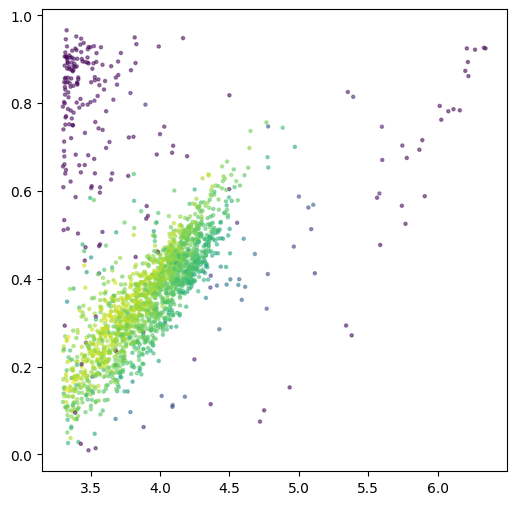

In [16]:
a_df = all_df[all_df['log(total_fragments)'] > 3.3]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(  a_df['log(total_fragments)'],  1 - a_df['P0_open_region'] ,
           c = a_df['frag_overlap_entropy_peaks%'],
           s=5, alpha=0.5)

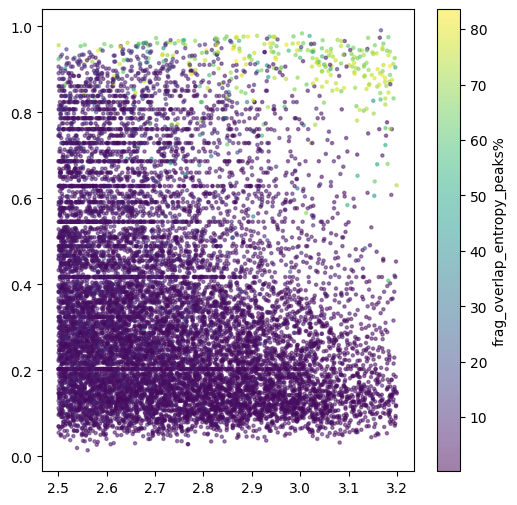

In [17]:
a_df = all_df[(all_df['log(total_fragments)'] > 2.5) & (all_df['log(total_fragments)'] < 3.2)]

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( a_df['log(total_fragments)'], 
              a_df['P0_open_region'], c= a_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

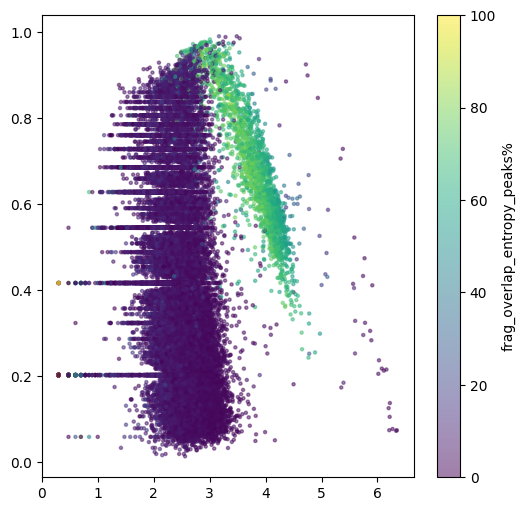

In [18]:

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter( all_df['log(total_fragments)'], 
              all_df['P0_open_region'], c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')

## Plot Mixture Entropy

In [19]:
## see different entropy calculation

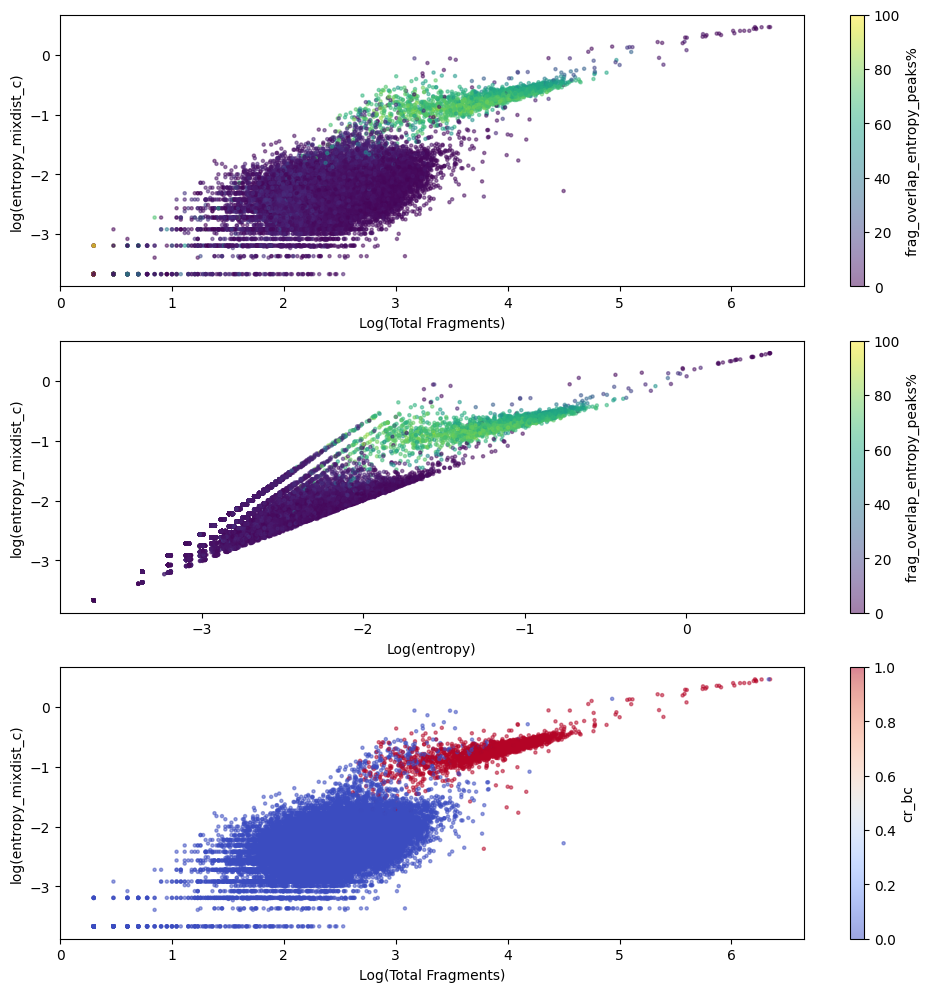

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')


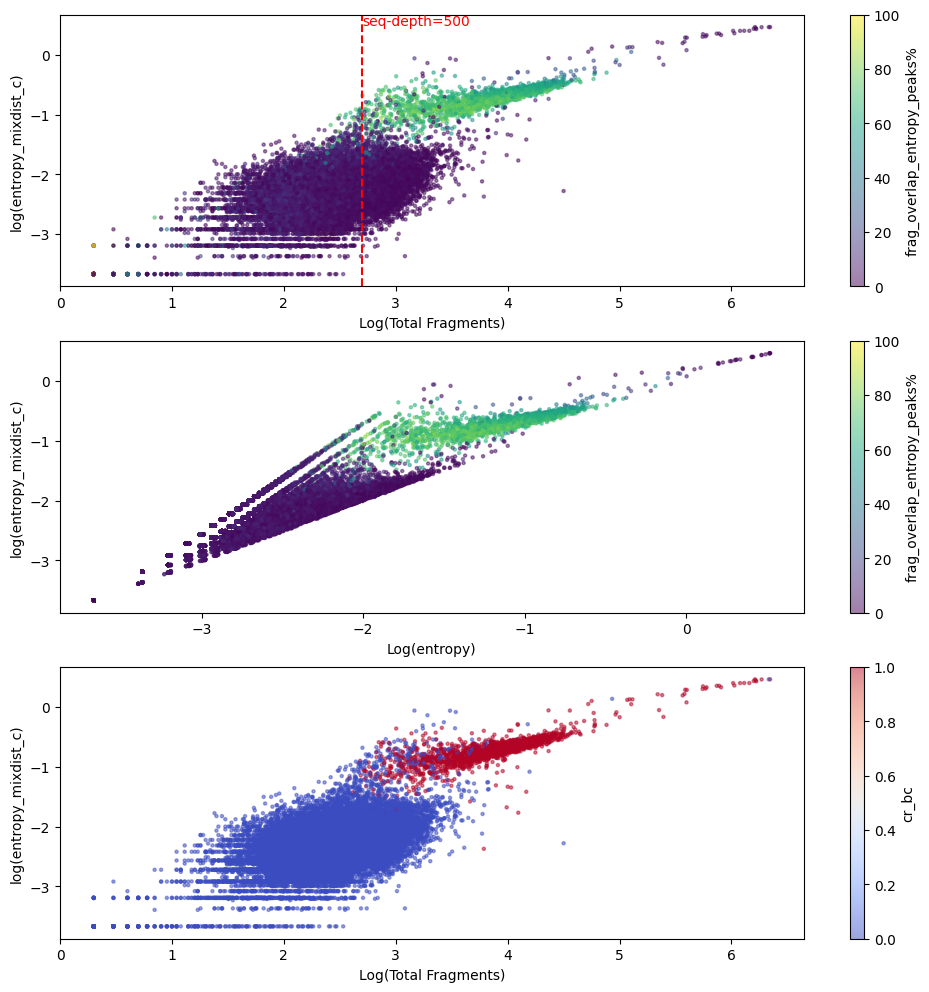

In [21]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')
ax[0].axvline(np.log10(500), color='red', linestyle='--', label='seq-depth=500')
ax[0].text(np.log10(500), .5, 'seq-depth=500', color='red')


ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

/home/syyang/python_virtuenv/mrvi_3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


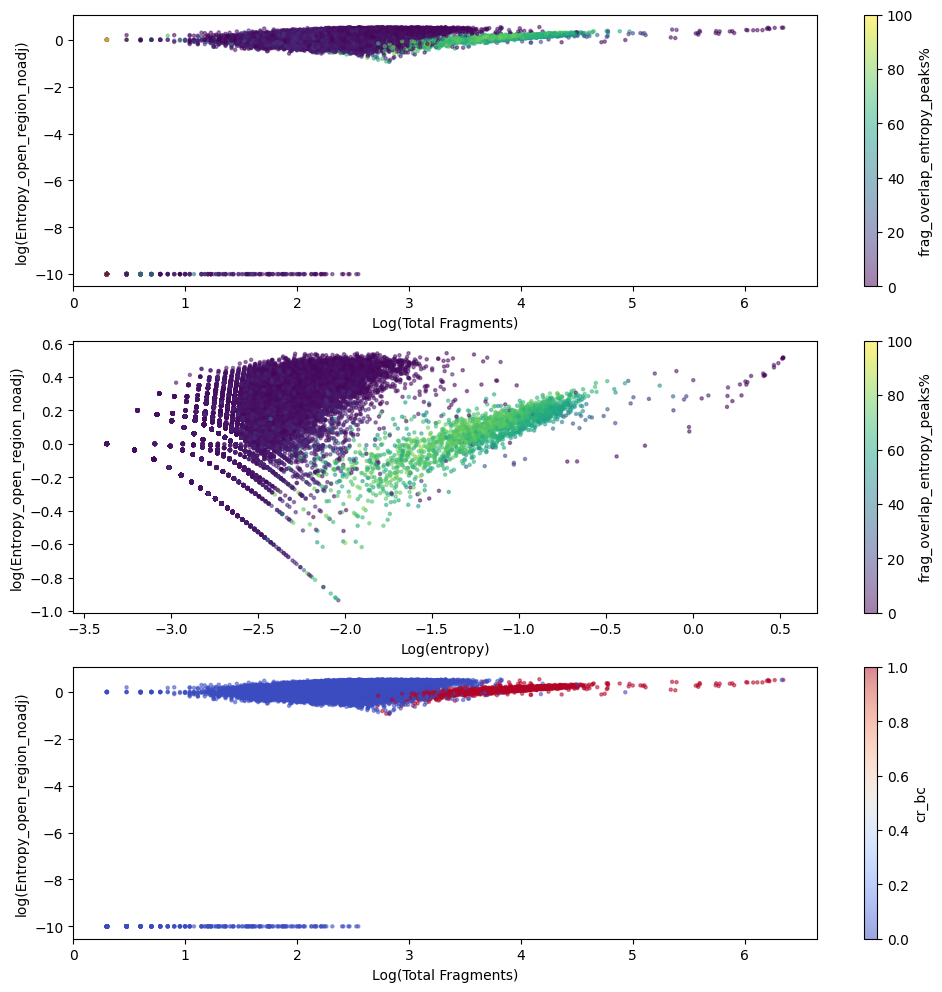

In [22]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_open_region_noadj']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(Entropy_open_region_noadj)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['Entropy_open_region_noadj']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(Entropy_open_region_noadj)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_open_region_noadj']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(Entropy_open_region_noadj)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

# And what

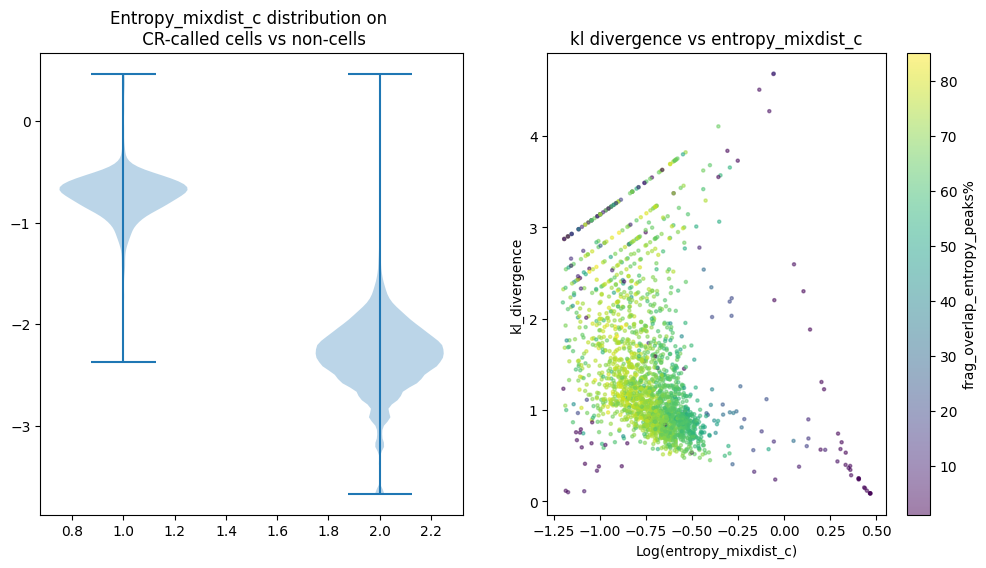

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixdist_c distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_mixdist_c'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_mixdist_c']), a_df['kl_divergence'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_mixdist_c)')
ax[1].set_ylabel('kl_divergence')
ax[1].set_title('kl divergence vs entropy_mixdist_c')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

In [24]:
all_df['entropy_pass'] = (all_df['entropy_mixdist_c'] > 10 ** (-1.1975644015016458))


In [25]:
(all_df['entropy_mixdist_c'] > 10 ** (-1.1975644015016458)).sum(), all_df['entropy_pass'].values.sum()

(2125, 2125)

In [34]:
all_df['identified_by'] = all_df.apply(
    lambda row: 'both' if row['entropy_pass'] and row['cr_bc'] else 
                ('entropy_only' if row['entropy_pass'] and not row['cr_bc'] else 
                 ('cr_only' if not row['entropy_pass'] and row['cr_bc'] else 'none')), axis=1
)

all_df['identified_by'].value_counts()

identified_by
none            286813
both              1888
entropy_only       237
cr_only             71
Name: count, dtype: int64

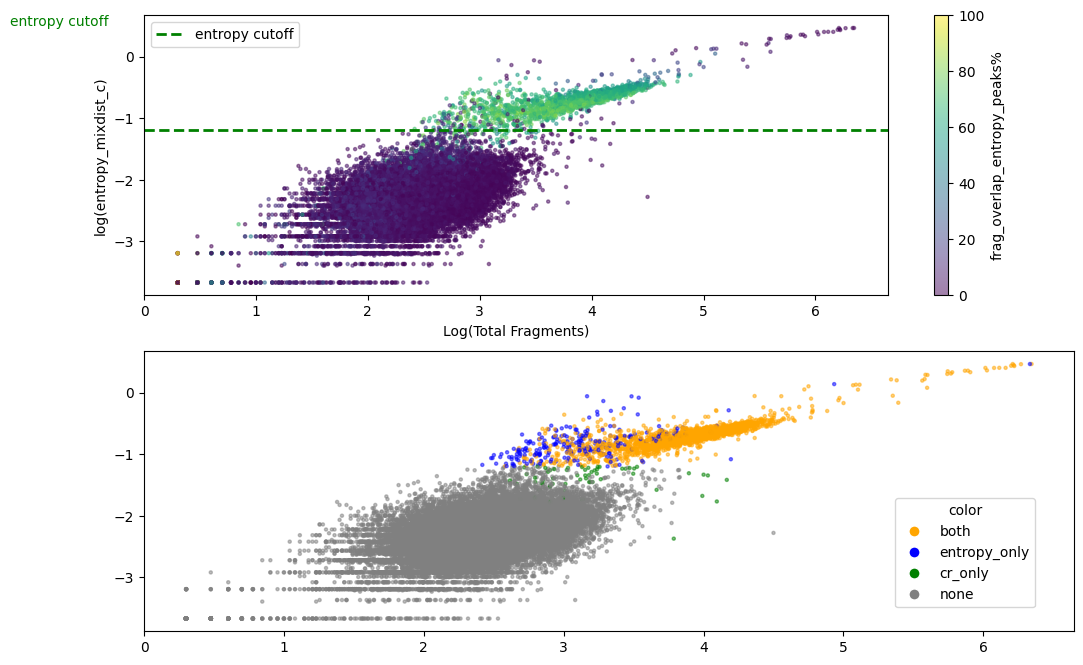

In [32]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8) )
colors = {'both':'orange', 'entropy_only':'blue', 'cr_only':'green', 'none':'gray'}
ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']),  c= all_df['identified_by'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax[1].legend(title='color', handles=handles, bbox_to_anchor=(0.8, 0.5), loc='upper left')

ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
ax[0].axhline(-1.1975644015016458, color='green', linestyle='--', label='entropy cutoff', lw=2)
ax[0].text(-1.1975644015016458, .5, 'entropy cutoff', color='green')
ax[0].legend()

fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

#ax.legend(handles=ax.scatter([], [], c='r', label='both').legend_elements()[0], labels=['both', 'entropy_only', 'cr_only', 'none'])



Text(0.5, 0, 'good bc identified by')

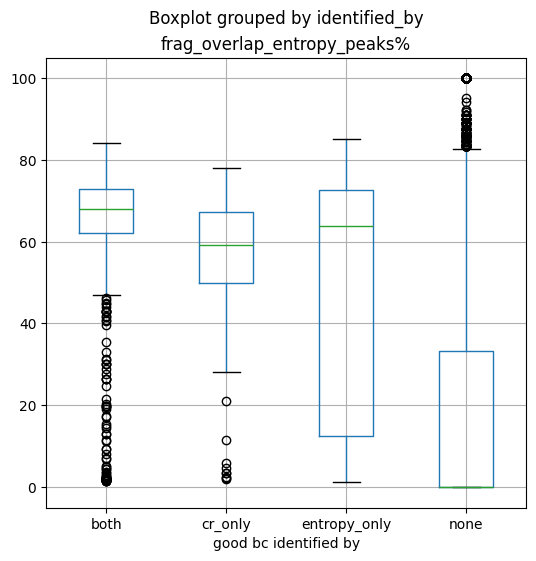

In [33]:
fig, ax = plt.subplots(figsize=(6,6))


all_df.boxplot(column=['frag_overlap_entropy_peaks%'], by='identified_by', ax=ax)
ax.set_xlabel('good bc identified by')

{'bodies': [<matplotlib.collections.PolyCollection at 0x714b7df250d0>,
 'cmeans': <matplotlib.collections.LineCollection at 0x714b7e071c10>,
 'cmaxes': <matplotlib.collections.LineCollection at 0x714b7e2d8750>,
 'cmins': <matplotlib.collections.LineCollection at 0x714b7e2b6990>,
 'cbars': <matplotlib.collections.LineCollection at 0x714b7e2dac10>}

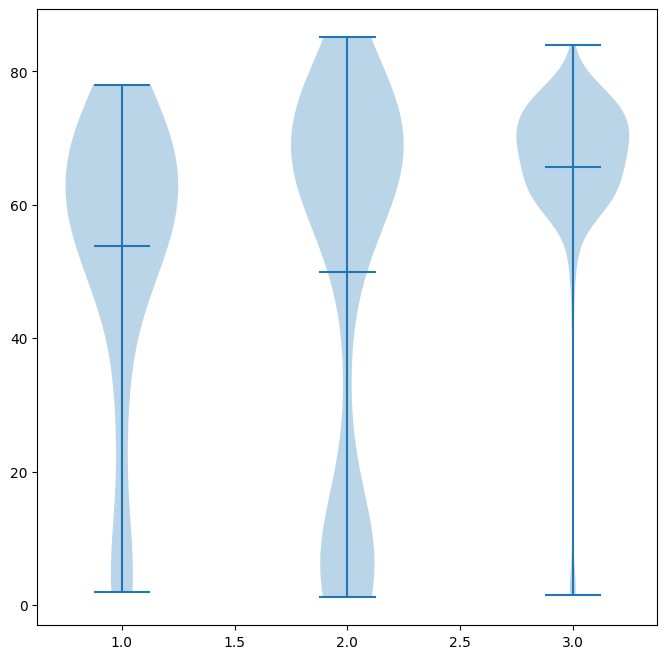

In [29]:
fig, ax = plt.subplots(figsize=(8,8))
ax.violinplot(
    [all_df.loc[all_df['identified_by'] == 'cr_only', 'frag_overlap_entropy_peaks%'], 
     all_df.loc[all_df['identified_by'] == 'entropy_only', 'frag_overlap_entropy_peaks%'],
     all_df.loc[all_df['identified_by'] == 'both', 'frag_overlap_entropy_peaks%']],
    positions=[1, 2, 3],
    showmeans=True
)

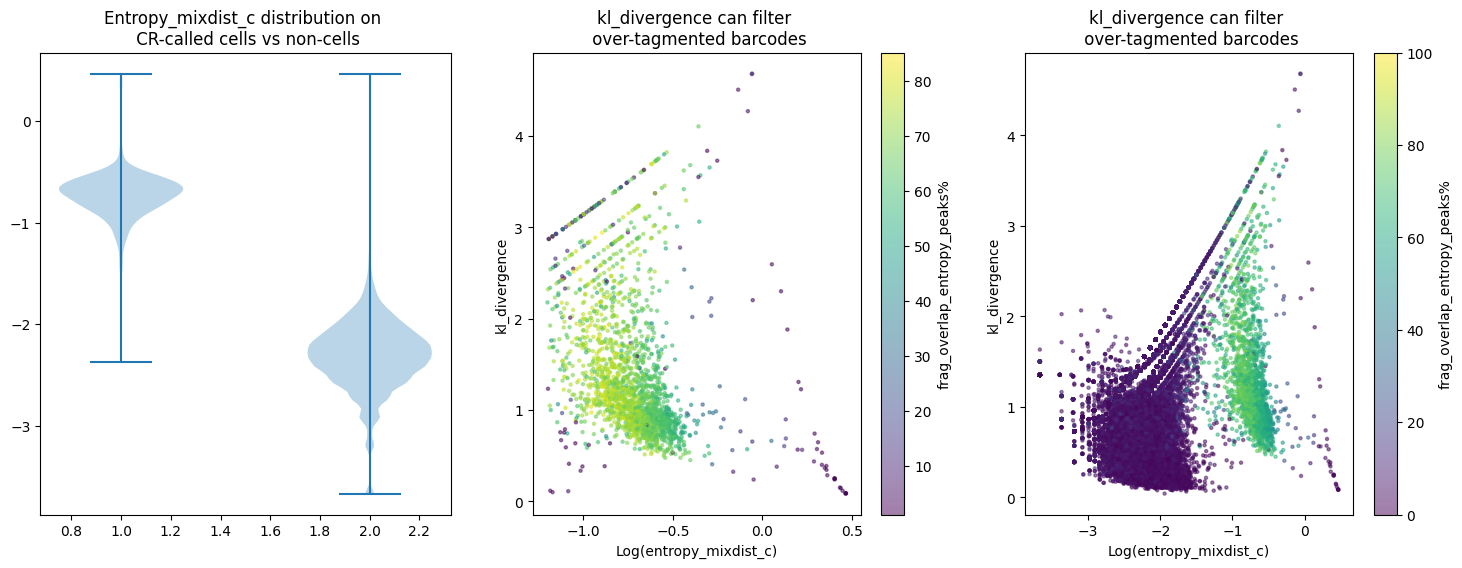

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(18 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'entropy_mixdist_c'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixdist_c distribution on \n CR-called cells vs non-cells')

a_df =  all_df[all_df['entropy_mixdist_c'] > 10 **(-1.2)]
ax[1].scatter(  np.log10(a_df['entropy_mixdist_c']), a_df['kl_divergence'],  c=a_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy_mixdist_c)')
ax[1].set_ylabel('kl_divergence')
ax[1].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')

ax[2].scatter(  np.log10(all_df['entropy_mixdist_c']), all_df['kl_divergence'],  c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('Log(entropy_mixdist_c)')
ax[2].set_ylabel('kl_divergence')
ax[2].set_title('kl_divergence can filter \n over-tagmented barcodes')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='frag_overlap_entropy_peaks%')

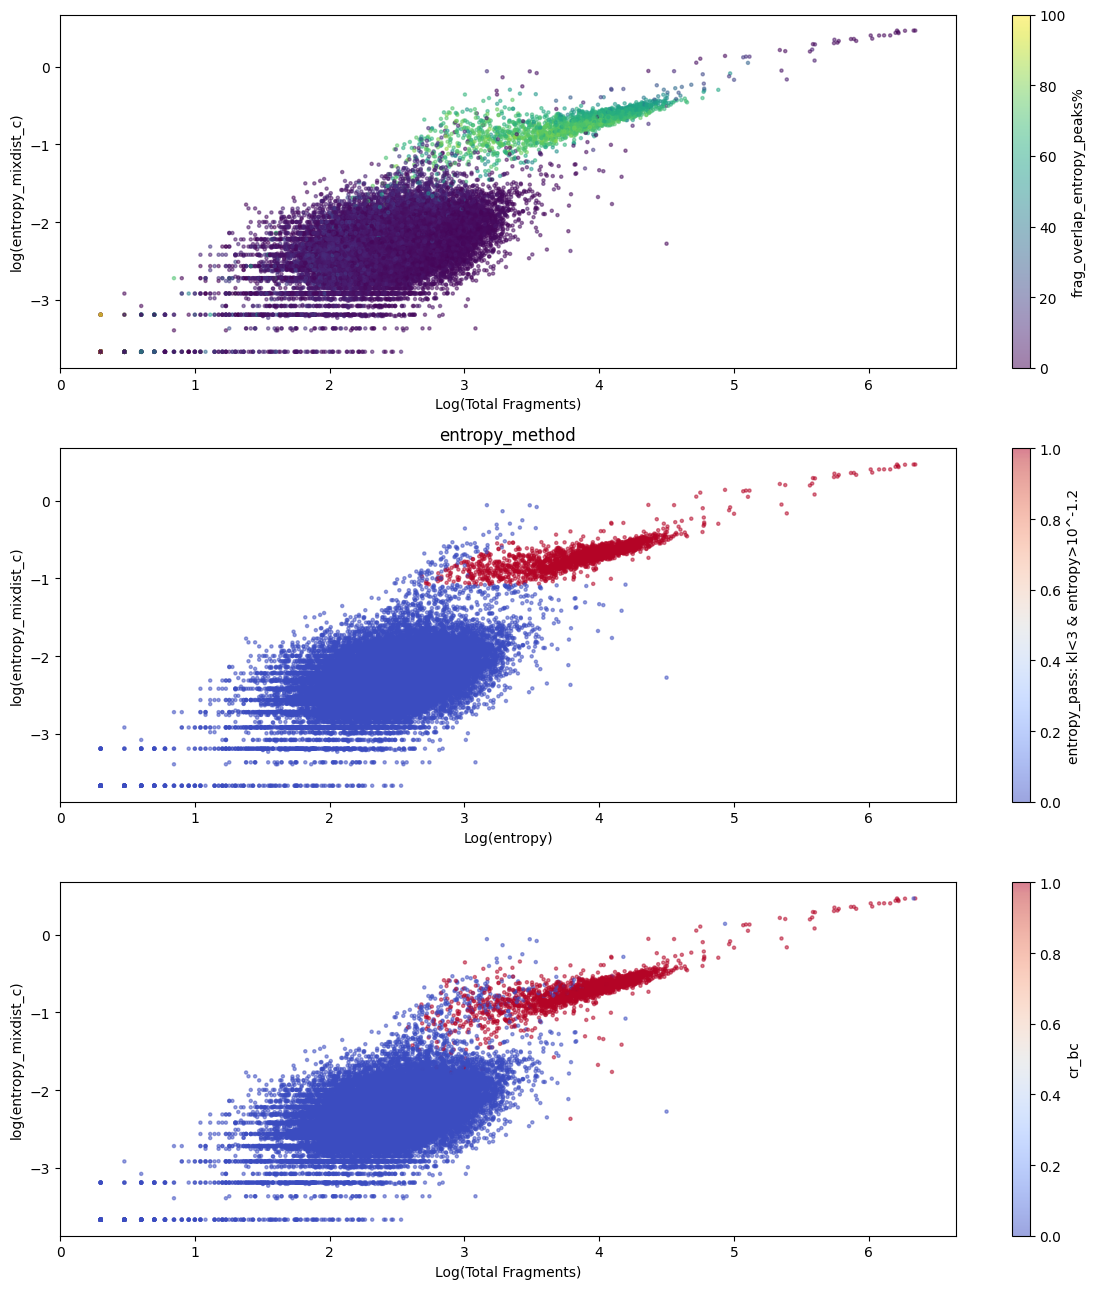

In [31]:
fig, ax = plt.subplots(3, 1, figsize=(12,13))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']),  c=all_df['entropy_pass'], 
           alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
ax[1].set_title('entropy_method')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='entropy_pass: kl<3 & entropy>10^-1.2')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist_c']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist_c)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

fig.tight_layout()

## Top 20k as pre-filter 

In [32]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)

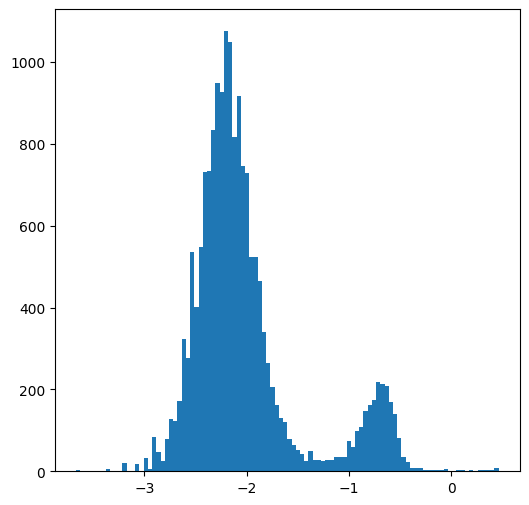

In [33]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['entropy_mixdist_c']), bins=100)

In [34]:
all_df['cr_bc'].value_counts()

cr_bc
False    287050
True       1959
Name: count, dtype: int64

In [35]:
all_df[all_df['entropy_mixdist_c'] > 10**(-1.0790962612777066)].shape

(2034, 20)

Text(0.5, 0, 'Ranked Barcodes (by entropy_mixdist_c)')

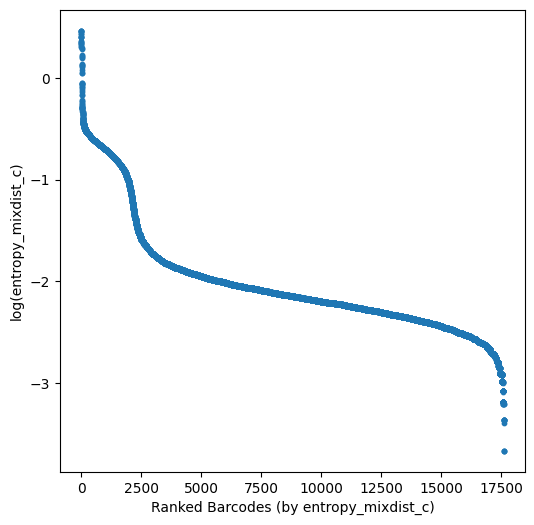

In [36]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['entropy_mixdist_c'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(entropy_mixdist_c)')
ax.set_xlabel('Ranked Barcodes (by entropy_mixdist_c)')

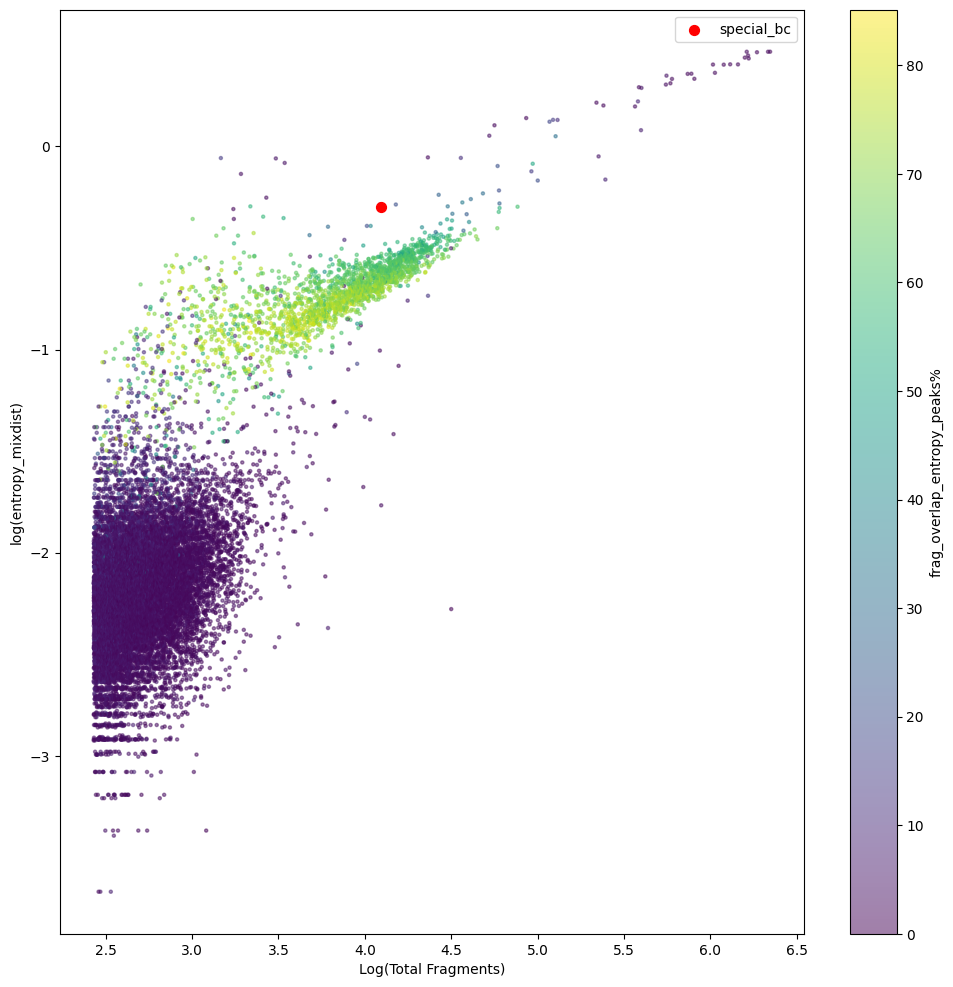

In [38]:


special_bc = 'GACAGGCTCGAGGAGG-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots( figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['entropy_mixdist_c']), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(entropy_mixdist)')
ax.scatter(top20k_df.loc[special_bc, 'log(total_fragments)'], np.log10(top20k_df.loc[special_bc, 'entropy_mixdist_c'] + precision),
              color='red', s=50, label='special_bc')
ax.legend()


fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


# Non-0 window 

In [129]:
cell_df = all_df[ (all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['total_fragments_entropypeaks'] < 10000)].copy()

special_bc = list(tn5_insert_freq.keys())[0]
total_windows = tn5_insert_freq[special_bc].shape[1] 

cell_df['N_open_regions'] = total_windows * (1 - cell_df['P_closed_state'])

for bc in cell_df.index:
    cell_df.loc[bc, 'N_nnz'] = tn5_insert_freq[bc].nnz

In [130]:
tn5_insert_freq[special_bc].nnz

756

In [131]:
cell_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,Entropy_open_region_noadj,...,P0_open_region,P_closed_state,kl_divergence,1-P0,Cluster,log(total_fragments),log(entropy),cr_bc,N_open_regions,N_nnz
AAACAAGCAAGTTAGT-1,2412,1730.0,71.724710,2412,1724.0,71.475954,0.030063,0.233120,0.425785,0.750521,...,0.919168,0.965127,2.516611,0.080832,3.0,3.382377,-1.521975,True,2894.0,234.0
AAACAAGCATTTCTTC-1,9030,1547.0,17.131783,9030,1540.0,17.054264,0.033346,0.085113,1.180950,1.331483,...,0.669833,0.990950,1.110677,0.330167,7.0,3.955688,-1.476951,True,751.0,248.0
AAACCGCCAACGGTAC-1,1731,1273.0,73.541306,1731,1265.0,73.079145,0.023550,0.158913,0.509842,0.515469,...,0.897148,0.978804,2.276520,0.102852,3.0,3.238297,-1.628010,True,1759.0,181.0
AAACCGCCAGAAACCC-1,786,401.0,51.017812,786,399.0,50.763359,0.012284,0.114782,0.377636,0.874634,...,0.931053,0.985504,2.675299,0.068947,5.0,2.895423,-1.910652,True,1203.0,83.0
AAACGAACACCTGTAT-1,1963,1157.0,58.940397,1963,1148.0,58.481915,0.023378,0.220508,0.360291,0.646650,...,0.935151,0.967115,2.736462,0.064849,2.0,3.292920,-1.631190,True,2729.0,177.0


(0.0, 20000.0)

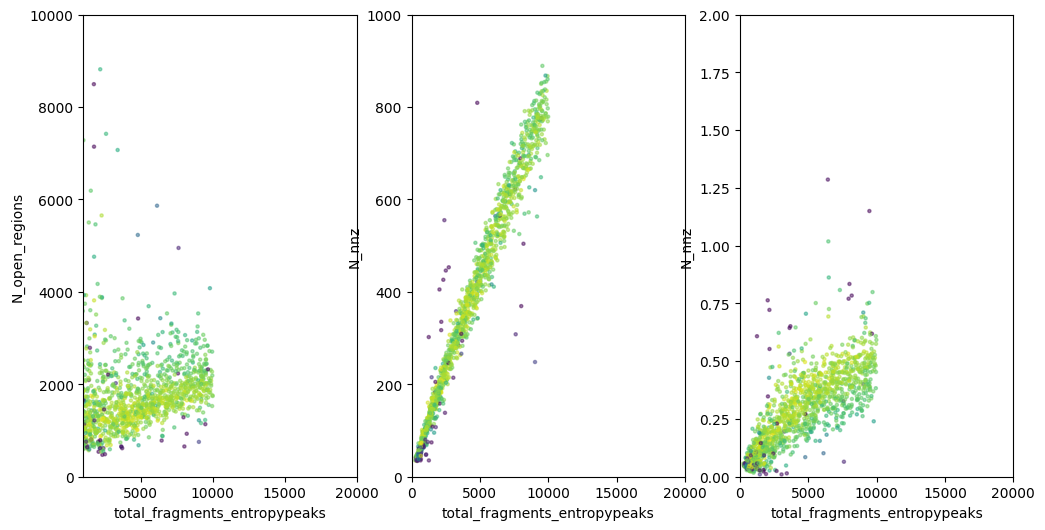

In [132]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
ax[0].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_open_regions'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('total_fragments_entropypeaks')       
ax[0].set_ylabel('N_open_regions')
ax[0].set_ylim(0, 10000)
ax[0].set_xlim(1000, 20000)


ax[1].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('total_fragments_entropypeaks')       
ax[1].set_ylabel('N_nnz')
ax[1].set_ylim(0, 1000)
ax[1].set_xlim(0, 20000)

ax[2].scatter( cell_df['total_fragments_entropypeaks'], cell_df['mle_lambda'], c=cell_df['frag_overlap_entropy_peaks%'], 
              alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('total_fragments_entropypeaks')       
ax[2].set_ylabel('N_nnz')
ax[2].set_ylim(0, 2)
ax[2].set_xlim(0, 20000)

In [136]:
cell_df['total_fragments_entropypeaks'].min()

262

## linear regression on read-depth v.s. non-zero winds N-nnz 

(array([[0.08073949]]), array([26.62998098]))

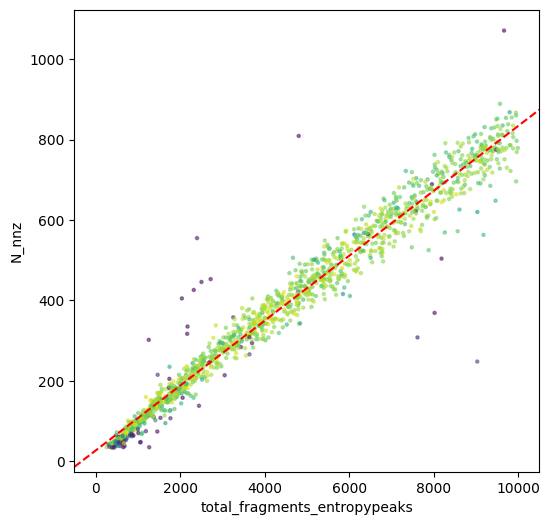

In [133]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(  cell_df['total_fragments_entropypeaks'].values.reshape(-1, 1), cell_df['N_nnz'].values.reshape(-1, 1),)

reg.coef_, reg.intercept_

x_s = np.array([0, 10000]).reshape(-1, 1)
y_s = reg.predict(x_s)
pts = np.concatenate([x_s, y_s], axis=1)

fig, ax = plt.subplots( figsize=(6,6))
ax.scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('total_fragments_entropypeaks')       
ax.set_ylabel('N_nnz')
# ax.set_ylim(0, 1000)
# ax.set_xlim(0, 20000)
ax.axline(pts[0], pts[1], color='red', linestyle='--', label='Linear Regression')

reg.coef_, reg.intercept_


In [140]:
(54  - reg.intercept_[0]) / reg.coef_[0][0]

338.99172115160144

In [145]:
32 / 0.0807

396.5303593556382

In [141]:
depth = 262
np.log10(depth),  depth * reg.coef_[0][0] + reg.intercept_[0]

(2.4183012913197452, 47.783727622758995)

# See Tn5 Insertions

## Set 1

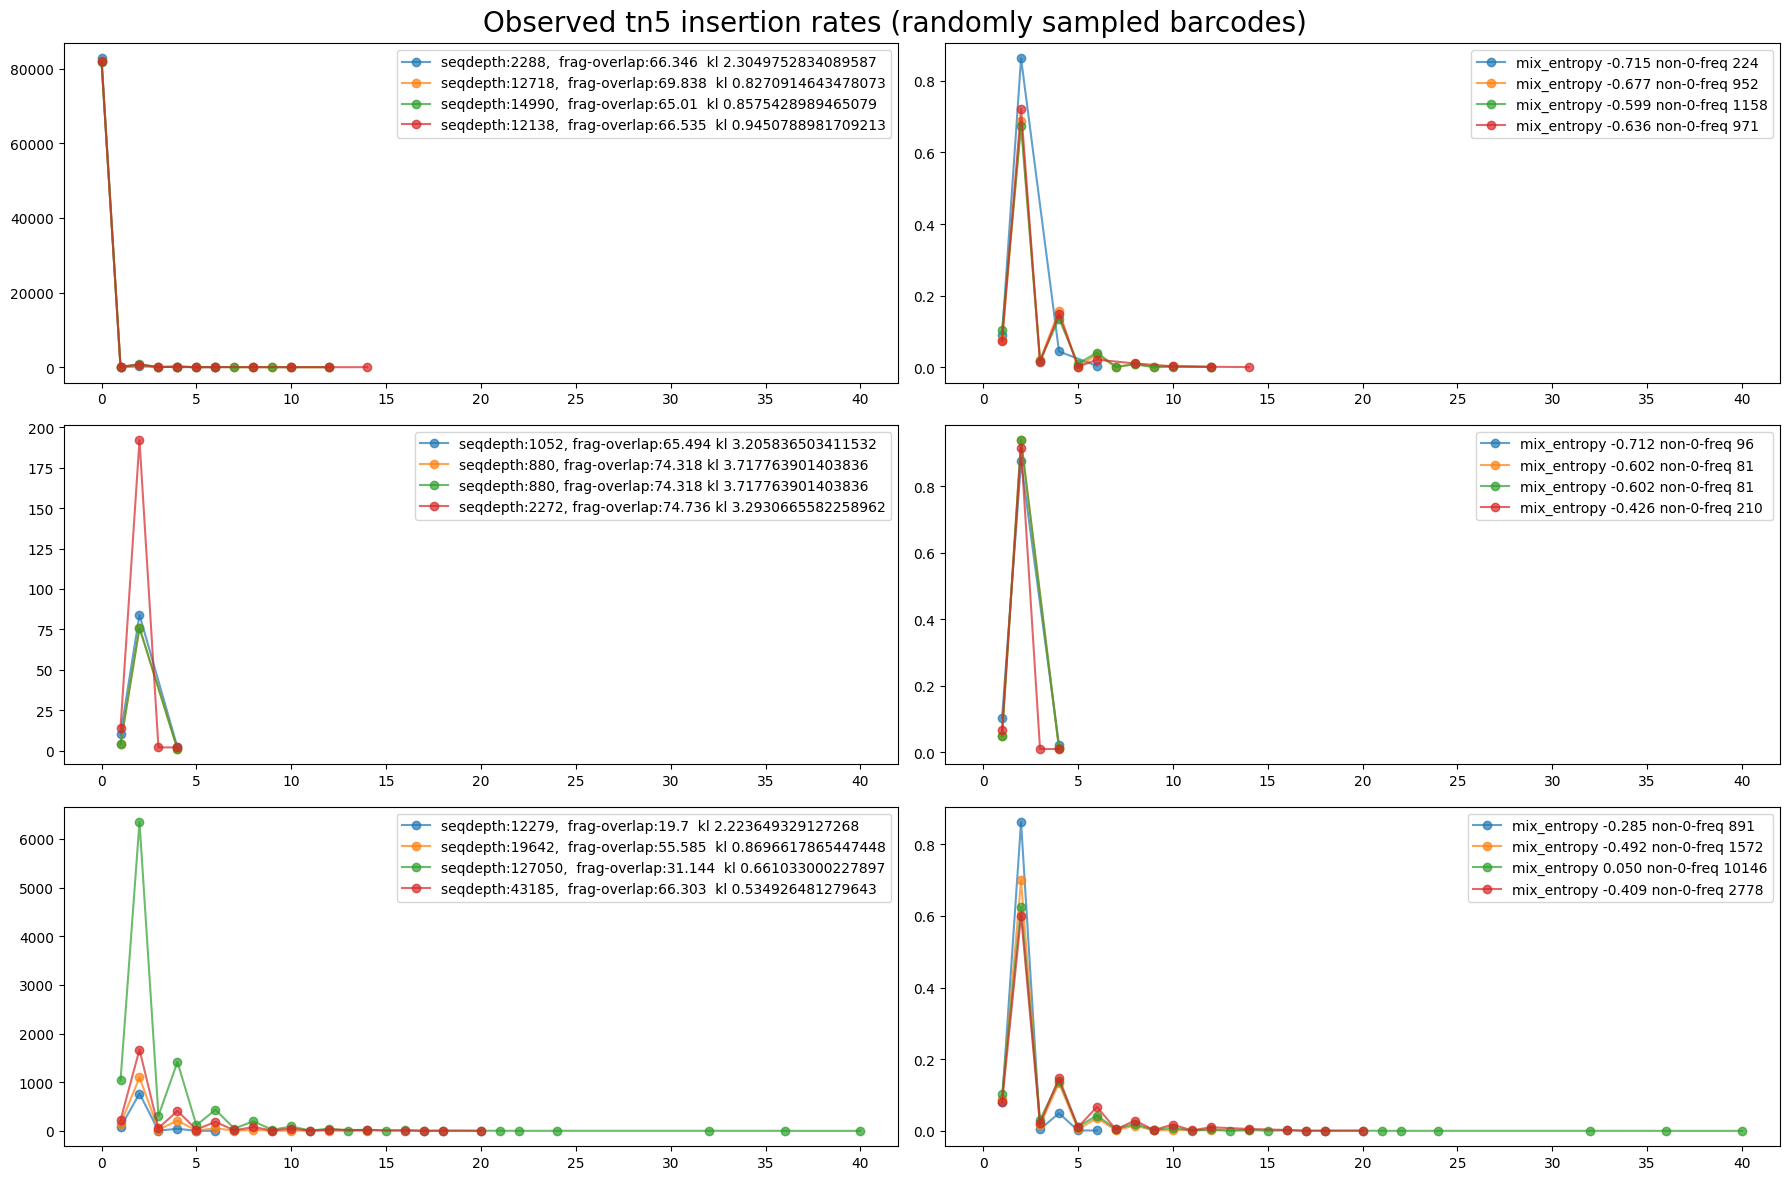

In [72]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-.8)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 66, 70# 82 , 82 seed is vip 

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, frag-overlap:{np.round(bc_frag_overlap, 3)} kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()} ',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

fig.suptitle('Observed tn5 insertion rates (randomly sampled barcodes)', fontsize=20)
fig.tight_layout()

total_fragments_entropypeaks        3438
frag_overlap_entropy_peaks         137.0
frag_overlap_entropy_peaks%     3.984875
total_fragments_peaks               3438
frag_overlap_peaks                 135.0
frag_overlap_peaks%             3.926702
entropy                         0.034753
entropy_mixdist_c               0.829877
entropy_open_region             0.106833
Entropy_open_region_noadj       0.523931
mle_lambda                      0.014052
P0_open_region                  0.986047
P_closed_state                  0.754742
1-P0                            0.013953
kl_divergence                    4.27207
Cluster                              NaN
log(total_fragments)            3.536306
log(entropy)                   -1.459007
cr_bc                              False
entropy_pass                       False
Name: AATCATGAGTATCGCC-1, dtype: object

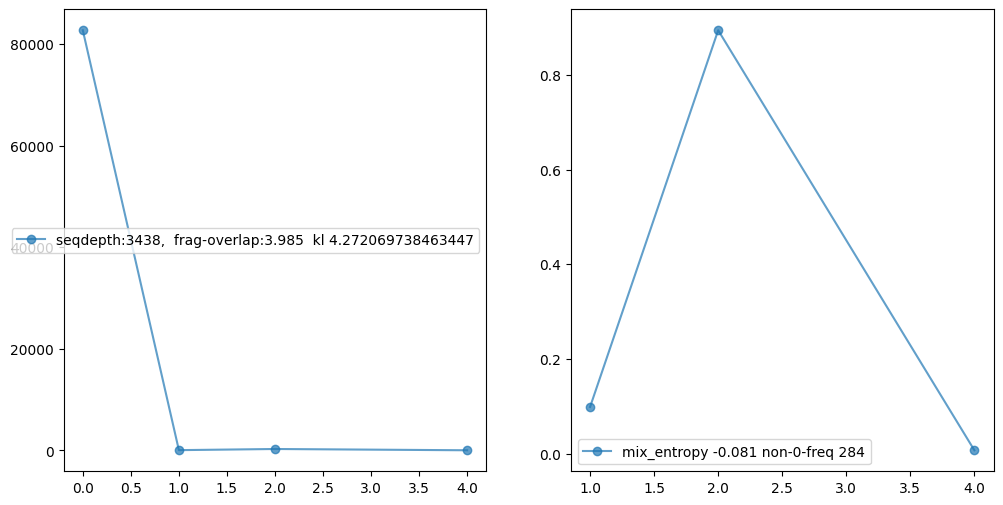

In [ ]:
bc = 'AATCATGAGTATCGCC-1'

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
bc_seq_depth = int(all_df.loc[bc, 'total_fragments_entropypeaks'])
bc_logentropy_val = all_df.loc[bc, 'log(entropy)']
bc_frag_overlap = all_df.loc[bc, 'frag_overlap_entropy_peaks%']
entropy_mix = all_df.loc[bc, 'entropy_mixdist_c']
kl_divergence_val = all_df.loc[bc, 'kl_divergence']

val, freq = np.unique(tn5_insert_freq[bc].toarray(), return_counts=True)
p_non0 = freq[1:]/  np.sum(freq[1:])     
ax[0].plot(val, freq, marker='o', 
        label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
ax[ 0].tick_params(labelbottom=True)

ax[ 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)
ax[0].legend()
ax[1].legend()

all_df.loc['AATCATGAGTATCGCC-1']


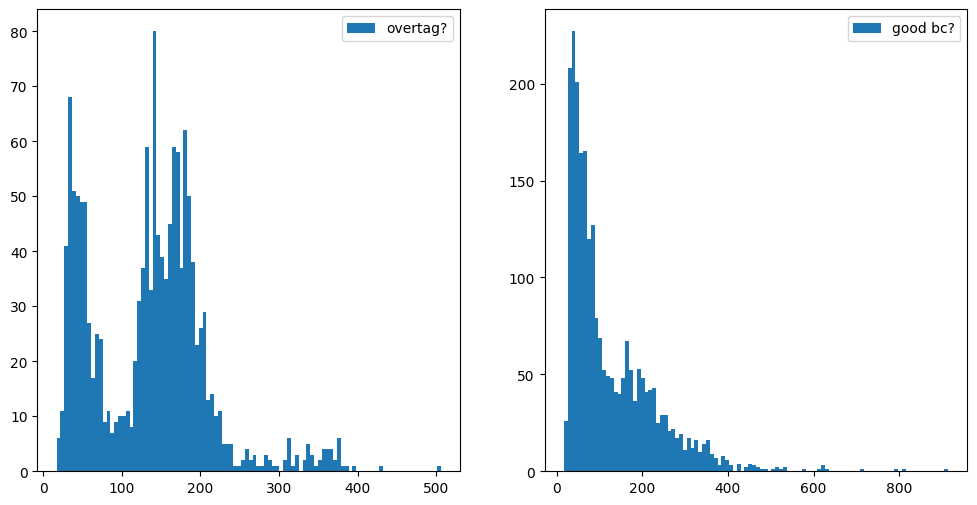

In [104]:
possible_overtag_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_overtag_bc_frag.tsv', sep='\t', header=None)
fig, ax = plt.subplots(1, 2, figsize=(12,6))

possible_good_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_goodbc_frag.tsv', sep='\t', header=None)

ax[0].hist(possible_overtag_bc_frag[2] - possible_overtag_bc_frag[1], log=False, bins=100, label='overtag?')

ax[1].hist(possible_good_bc_frag[2] - possible_good_bc_frag[1], log=False, bins=100, label='good bc?')

ax[0].legend()
ax[1].legend()

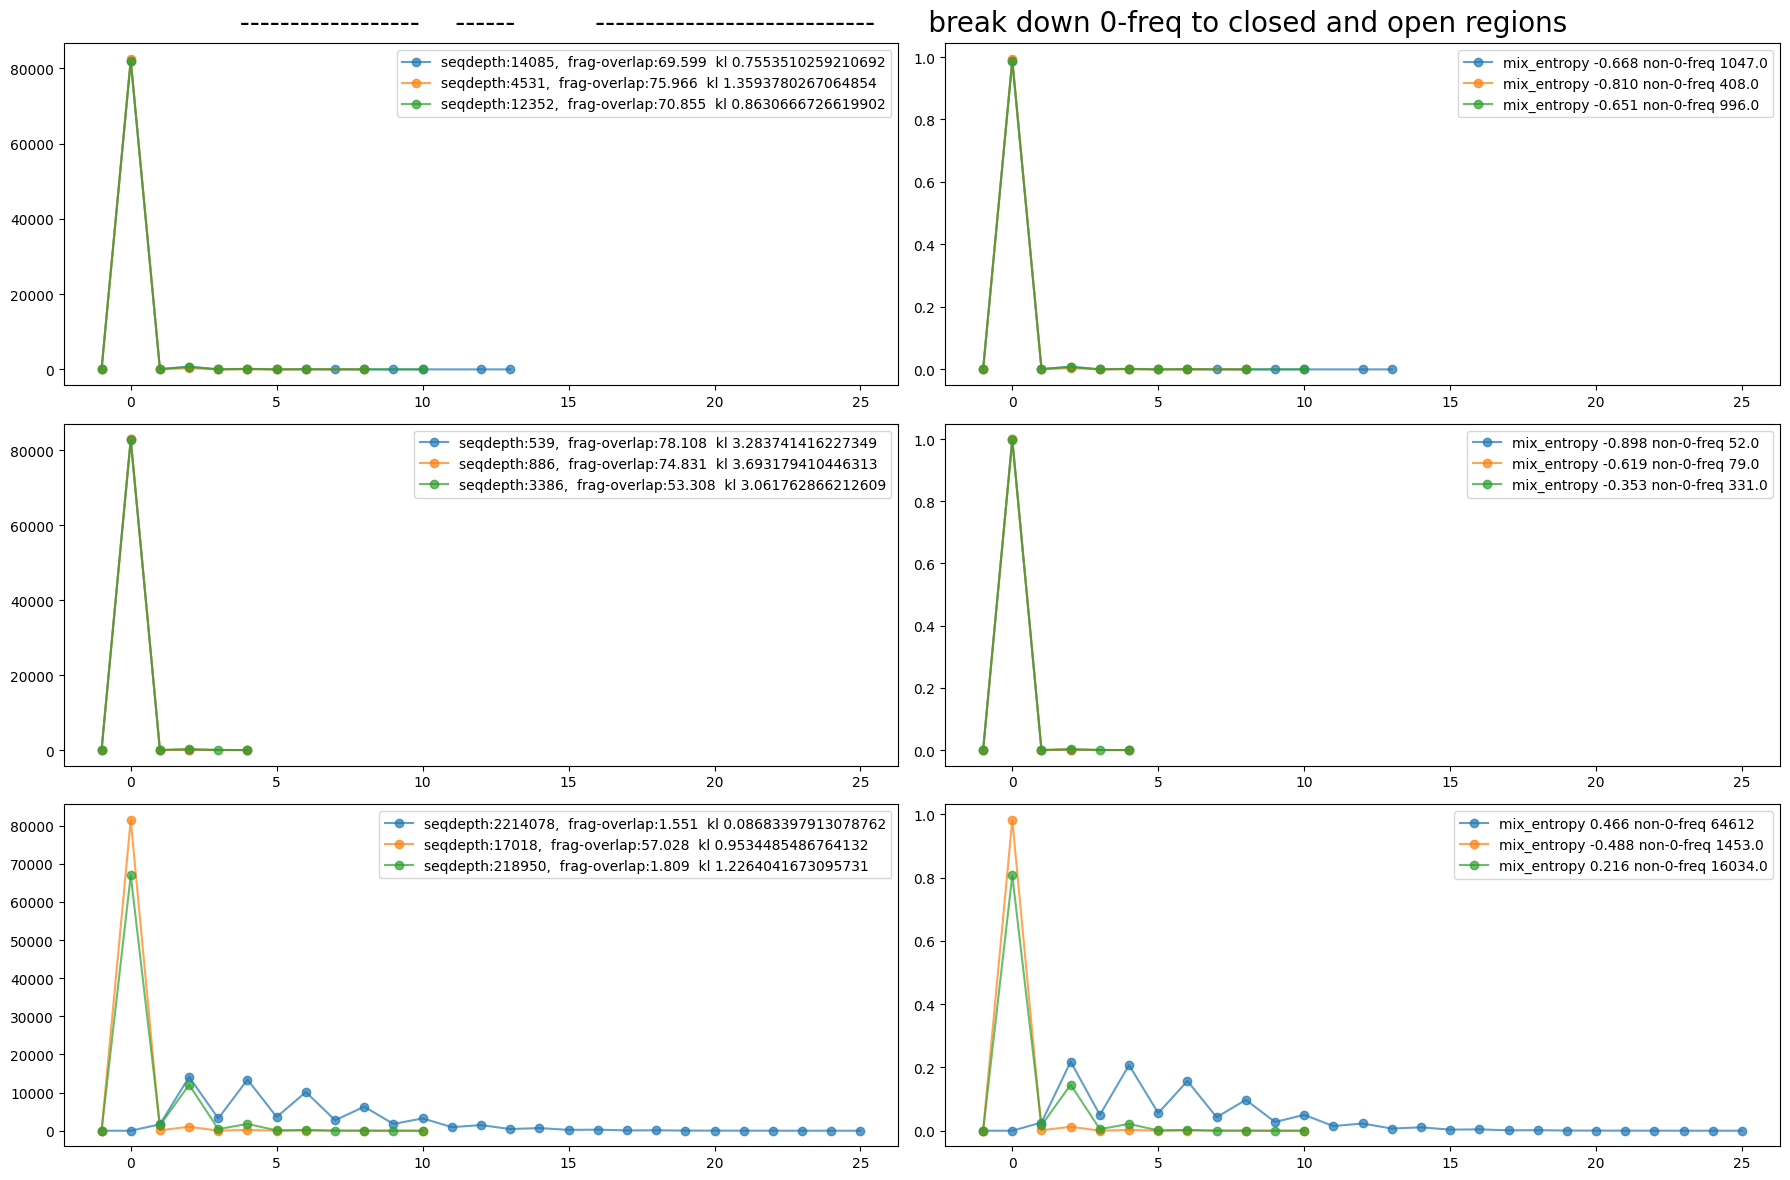

In [90]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq)     

        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()
        
fig.suptitle('  ------------------    ------         ----------------------------      break down 0-freq to closed and open regions', fontsize=20)
fig.tight_layout()

In [93]:
all_df.loc['CTCAGCTAGCCAGTAG-1']

total_fragments_entropypeaks         4531
frag_overlap_entropy_peaks         3442.0
frag_overlap_entropy_peaks%     75.965571
total_fragments_peaks                4531
frag_overlap_peaks                 3431.0
frag_overlap_peaks%             75.722798
entropy                          0.050969
entropy_mixdist_c                 0.15487
entropy_open_region              0.994699
Entropy_open_region_noadj        1.259601
mle_lambda                       0.298861
P0_open_region                   0.741662
P_closed_state                   0.980973
1-P0                             0.258338
kl_divergence                    1.359378
Cluster                               3.0
log(total_fragments)             3.656194
log(entropy)                    -1.292696
cr_bc                                True
entropy_pass                         True
Name: CTCAGCTAGCCAGTAG-1, dtype: object

In [64]:
np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)[1].sum()

82986

In [85]:
all_df.loc[((all_df['kl_divergence'] > 4) & (all_df['log(total_fragments)'] > 3))]

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,entropy_mixdist_c,entropy_open_region,Entropy_open_region_noadj,mle_lambda,P0_open_region,P_closed_state,1-P0,kl_divergence,Cluster,log(total_fragments),log(entropy),cr_bc,entropy_pass
AATCATGAGTATCGCC-1,3438,137.0,3.984875,3438,135.0,3.926702,0.034753,0.829877,0.106833,0.523931,0.014052,0.986047,0.754742,0.013953,4.272070,NaN,3.536306,-1.459007,False,False
AGCTAACAGCCTGGTT-1,3055,131.0,4.288052,3055,131.0,4.288052,0.027074,0.873433,0.076435,0.458812,0.009331,0.990712,0.722363,0.009288,4.679059,NaN,3.485011,-1.567453,False,False
AGTGCCCGTTGAGGGT-1,1469,207.0,14.091219,1469,206.0,14.023145,0.027548,0.877099,0.076143,0.599870,0.009288,0.990755,0.719772,0.009245,4.683692,NaN,3.167022,-1.559907,False,False
GAATATCCATAATCGG-1,1920,62.0,3.229167,1920,61.0,3.177083,0.023776,0.732521,0.088090,0.671825,0.011091,0.988971,0.803340,0.011029,4.507217,NaN,3.283301,-1.623855,False,False
TCTTACTGTCATTACA-1,1009,660.0,65.411298,1009,654.0,64.816650,0.016503,0.439566,0.122359,0.537253,0.016621,0.983517,0.912274,0.016483,4.105456,4.0,3.003891,-1.782439,True,False


## Set 2

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = bad_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())

        val = val[freq != None]
        freq = freq[freq != None]
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

# Plot entropy of mixture distribution

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')